# Laporan Tugas Akhir (Tahap 4)

**Topik:** Problem 12: Manufaktur - Optimasi Penjadwalan Pemeliharaan Mesin  
**Anggota Kelompok:** Kelompok Ayayo Team  
- Rafa Suryaputra: 103012580048  
- Firdaus Akbar Amrullah: 103012580011  
- Muhammad Raihan Fahrifi: 103012580017

Laporan Akhir : Prediksi sisa umur mesin dan penyusunan jadwal perbaikan 50 mesin kritis dengan Machine Learning dan Algoritma Genetika.

## A. Pendahuluan dan Paparan Data

Kami menyelesaikan masalah penjadwalan perbaikan 50 mesin kritis pada pabrik manufaktur yang beroperasi 24 jam. Setiap mesin memiliki sisa umur mesin dan durasi perbaikan yang berbeda. Karena tim teknisi hanya satu, perbaikan dilakukan satu per satu. Mesin dihitung breakdown jika waktu mulai perbaikannya sudah melewati sisa umur yang diprediksi.

Dataset yang kami gunakan adalah `ds12_manufaktur_maintenance.csv`. Target prediksi adalah `sisa_umur_jam`. Fitur yang digunakan berasal dari data sensor dan data operasional mesin.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
from IPython.display import display, Image
from sklearn.model_selection import train_test_split

pd.set_option('display.float_format', lambda value: f'{value:,.4f}')

ROOT = Path(r'D:\tubes_ka')
DATASET = ROOT / 'ds12_manufaktur_maintenance.csv'
STAGE1 = ROOT / 'tahap 1'
STAGE2 = ROOT / 'tahap 2'
STAGE3 = ROOT / 'tahap 3'

metrics_path = STAGE1 / 'outputs' / 'metrics' / 'tahap1_model_metrics.csv'
summary_path = STAGE1 / 'outputs' / 'metrics' / 'tahap1_summary.json'
ga_design_path = STAGE2 / 'outputs' / 'data' / 'tahap2_desain_ga.json'
ga_compare_path = STAGE2 / 'outputs' / 'data' / 'tahap2_evaluasi_fitness_jadwal.csv'
integration_summary_path = STAGE3 / 'outputs' / 'data' / 'tahap3_integration_summary.json'
history_path = STAGE3 / 'outputs' / 'data' / 'tahap3_ga_convergence_history.csv'
schedule_path = STAGE3 / 'outputs' / 'data' / 'tahap3_best_schedule_ga.csv'
interface_path = STAGE3 / 'outputs' / 'data' / 'tahap3_interface_ml_to_ga.csv'

df = pd.read_csv(DATASET)
model_metrics = pd.read_csv(metrics_path)
ga_compare = pd.read_csv(ga_compare_path)
history = pd.read_csv(history_path)
best_schedule = pd.read_csv(schedule_path)
interface_df = pd.read_csv(interface_path)

with open(summary_path, encoding='utf-8') as file:
    tahap1_summary = json.load(file)
with open(ga_design_path, encoding='utf-8') as file:
    ga_design = json.load(file)
with open(integration_summary_path, encoding='utf-8') as file:
    integration_summary = json.load(file)

print(f'Dataset: {DATASET.name}')
print(f'Ukuran dataset: {df.shape[0]:,} baris dan {df.shape[1]} kolom')
print(f'Jumlah mesin pada input GA: {len(interface_df)}')

Dataset: ds12_manufaktur_maintenance.csv
Ukuran dataset: 16,000 baris dan 10 kolom
Jumlah mesin pada input GA: 50


In [2]:
dataset_info = pd.DataFrame([
    {'komponen': 'Jumlah baris', 'nilai': df.shape[0]},
    {'komponen': 'Jumlah kolom', 'nilai': df.shape[1]},
    {'komponen': 'Target', 'nilai': 'sisa_umur_jam'},
    {'komponen': 'Jumlah data anomali untuk penjadwalan', 'nilai': len(interface_df)},
])

display(dataset_info)
display(df.head())

,komponen,nilai
0,Jumlah baris,16000
1,Jumlah kolom,10
2,Target,sisa_umur_jam
3,Jumlah data anomali untuk penjadwalan,50


,sisa_umur_jam,jam_operasi_aktif,jenis_mesin,tekanan_oli_bar,id_log_sensor,suhu_c,vibrasi_mm_s,durasi_perbaikan_jam,shift_operator,kebisingan_lingkungan_db
0,84.1000,2695,Robot_Arm,2.1500,LOG-00001,92.1000,3.4900,9,Shift_3,79.1000
1,221.1000,15705,Conveyor_Belt,2.2200,LOG-00002,41.6000,4.5100,5,Shift_3,73.1000
2,237.2000,13436,CNC_Milling,3.6000,LOG-00003,63.3000,2.1900,10,Shift_2,83.8000
3,258.2000,9338,CNC_Milling,4.3400,LOG-00004,50.6000,5.0000,9,Shift_2,86.2000
4,261.7000,9227,Robot_Arm,3.8500,LOG-00005,34.3000,5.5400,9,Shift_3,90.4000


Tabel ringkasan dataset memastikan data akhir yang digunakan sudah sesuai: 16.000 baris, 10 kolom, target `sisa_umur_jam`, dan 50 mesin untuk penjadwalan. Tampilan lima baris awal digunakan untuk melihat bentuk data sebelum masuk ke pembahasan hasil.

In [3]:
missing = df.isna().sum().reset_index()
missing.columns = ['kolom', 'jumlah_missing']
missing['persentase_missing'] = (missing['jumlah_missing'] / len(df) * 100).round(4)

target_stats = df['sisa_umur_jam'].describe().to_frame('sisa_umur_jam').T.round(4)
jenis_mesin_summary = pd.DataFrame(tahap1_summary['jenis_mesin_summary']).T
shift_summary = pd.DataFrame(tahap1_summary['shift_summary']).T

print('Missing value')
display(missing)
print('Statistik target RUL')
display(target_stats)
print('Ringkasan RUL per jenis mesin')
display(jenis_mesin_summary)
print('Ringkasan RUL per shift operator')
display(shift_summary)

Missing value


,kolom,jumlah_missing,persentase_missing
0,sisa_umur_jam,0,0.0000
1,jam_operasi_aktif,0,0.0000
2,jenis_mesin,0,0.0000
3,tekanan_oli_bar,0,0.0000
4,id_log_sensor,0,0.0000
5,suhu_c,38,0.2375
6,vibrasi_mm_s,0,0.0000
7,durasi_perbaikan_jam,0,0.0000
8,shift_operator,0,0.0000
9,kebisingan_lingkungan_db,0,0.0000


Statistik target RUL


,count,mean,std,min,25%,50%,75%,max
sisa_umur_jam,"16,000.0000",227.5924,56.4272,1.0000,210.7750,237.5000,265.0250,311.6000


Ringkasan RUL per jenis mesin


,count,mean,std,min,max
CNC_Milling,"6,306.0000",227.5720,56.4270,1.0000,311.6000
Conveyor_Belt,"3,205.0000",227.7420,55.9930,1.0000,309.3000
Robot_Arm,"6,489.0000",227.5380,56.6490,1.0000,311.0000


Ringkasan RUL per shift operator


,count,mean,std
Shift_1,"5,313.0000",228.2510,55.8690
Shift_2,"5,425.0000",227.8420,56.2920
Shift_3,"5,262.0000",226.6700,57.1220


Tabel missing value menunjukkan kondisi data sebelum preprocessing. Statistik target menjelaskan sebaran sisa umur mesin dalam satuan jam. Ringkasan per jenis mesin dan shift membantu melihat apakah nilai RUL tersebar cukup merata atau ada kelompok mesin tertentu yang lebih berisiko.

### Preprocessing dan Pembagian Data

Fitur prediksi sisa umur mesin adalah `jam_operasi_aktif`, `jenis_mesin`, `tekanan_oli_bar`, `suhu_c`, `vibrasi_mm_s`, `shift_operator`, dan `kebisingan_lingkungan_db`. Kolom `id_log_sensor` tidak digunakan sebagai fitur karena hanya menjadi kode log. Kolom `durasi_perbaikan_jam` digunakan pada tahap penjadwalan sebagai lama perbaikan setiap mesin.

Nilai kosong pada kolom numerik diisi dengan median. Nilai kosong pada kolom kategorikal diisi dengan nilai yang paling sering muncul, lalu diubah menjadi bentuk numerik. Model linear menggunakan standardisasi angka. Model berbasis pohon menggunakan data numerik setelah pengisian nilai kosong.

Data dibagi menjadi 70% training, 15% validasi, dan 15% testing. Nilai `random_state=42` digunakan agar hasil pembagian data tetap sama saat dijalankan ulang.

In [4]:
target = 'sisa_umur_jam'
features = [
    'jam_operasi_aktif', 'jenis_mesin', 'tekanan_oli_bar', 'suhu_c',
    'vibrasi_mm_s', 'shift_operator', 'kebisingan_lingkungan_db'
]

X = df[features]
y = df[target]

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.1764705882, random_state=42
)

split_table = pd.DataFrame([
    {'bagian_data': 'Training', 'jumlah_baris': len(X_train), 'persentase': len(X_train) / len(df) * 100},
    {'bagian_data': 'Validasi', 'jumlah_baris': len(X_val), 'persentase': len(X_val) / len(df) * 100},
    {'bagian_data': 'Testing', 'jumlah_baris': len(X_test), 'persentase': len(X_test) / len(df) * 100},
])
split_table['persentase'] = split_table['persentase'].round(2)
display(split_table)

,bagian_data,jumlah_baris,persentase
0,Training,11200,70.0000
1,Validasi,2400,15.0000
2,Testing,2400,15.0000


Tabel pembagian data menunjukkan proporsi training, validasi, dan testing. Pembagian ini dibuat agar model tidak hanya bagus saat dilatih, tetapi juga tetap diuji pada data yang tidak digunakan dalam pemilihan model.

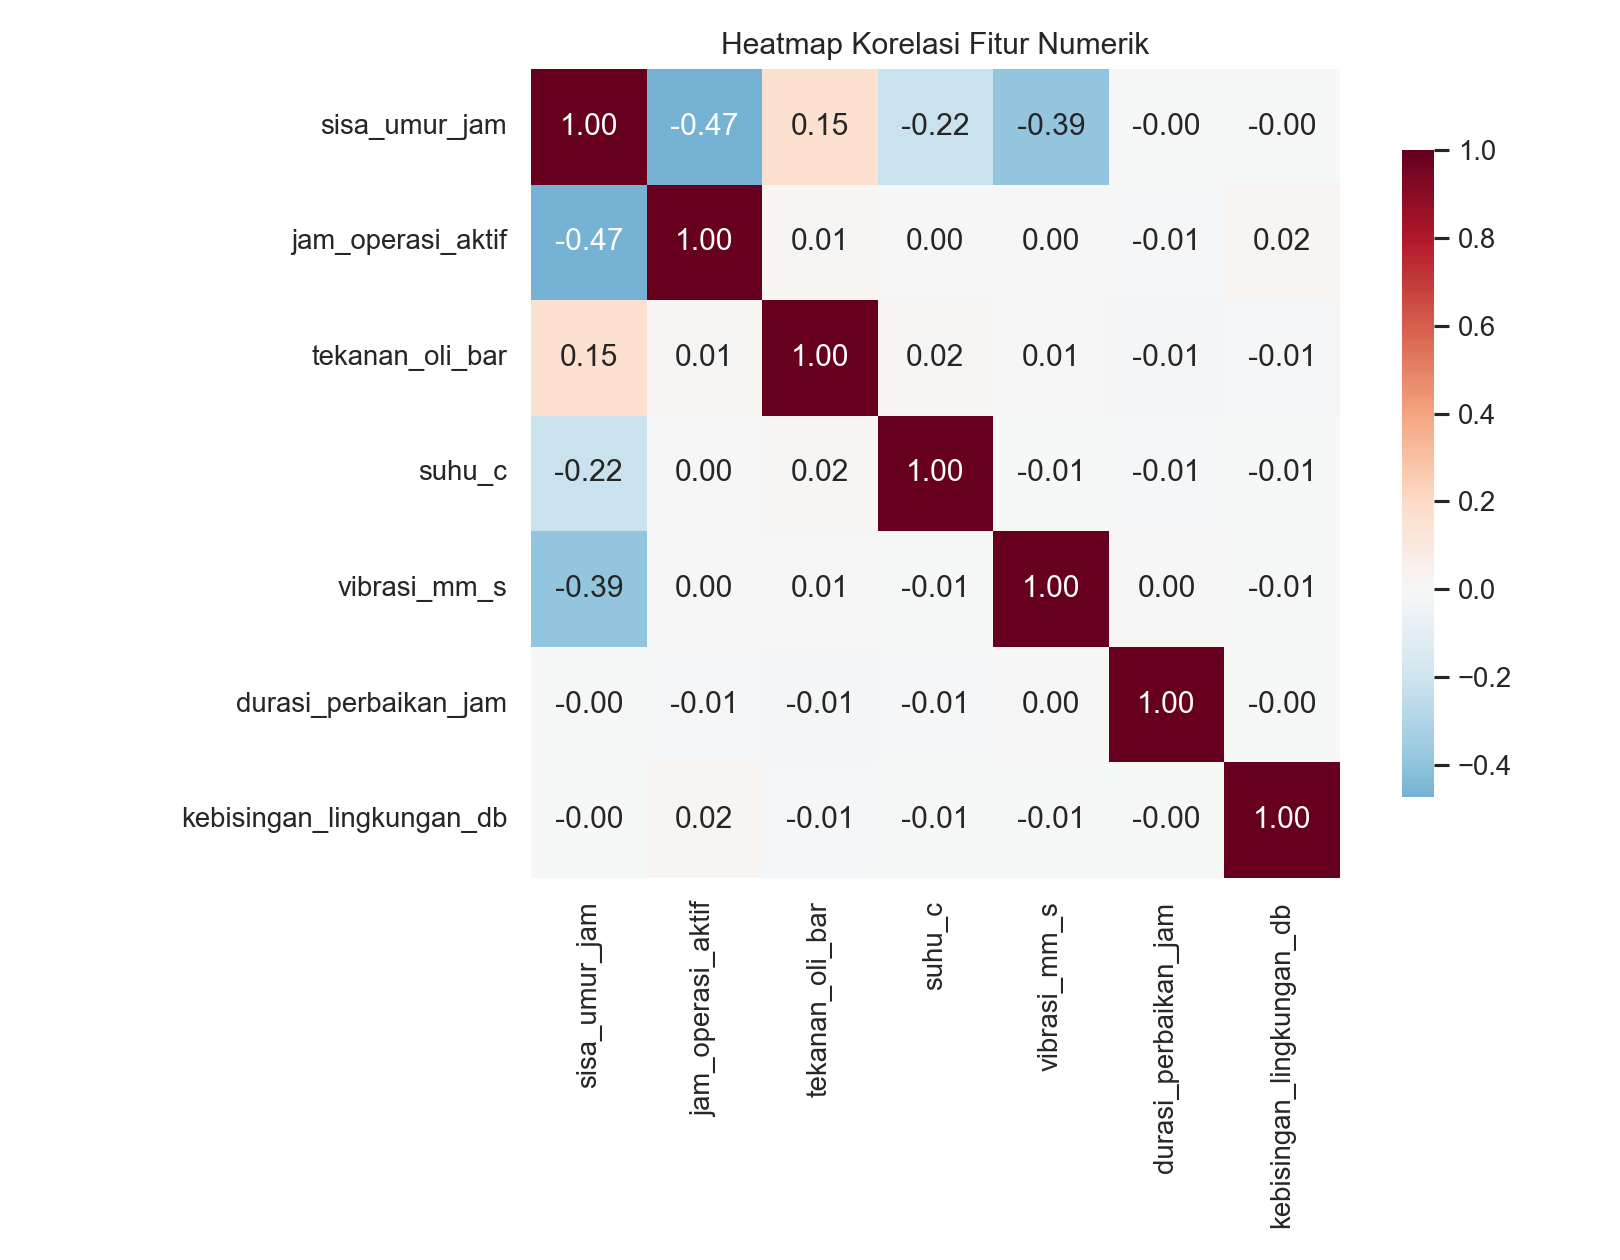

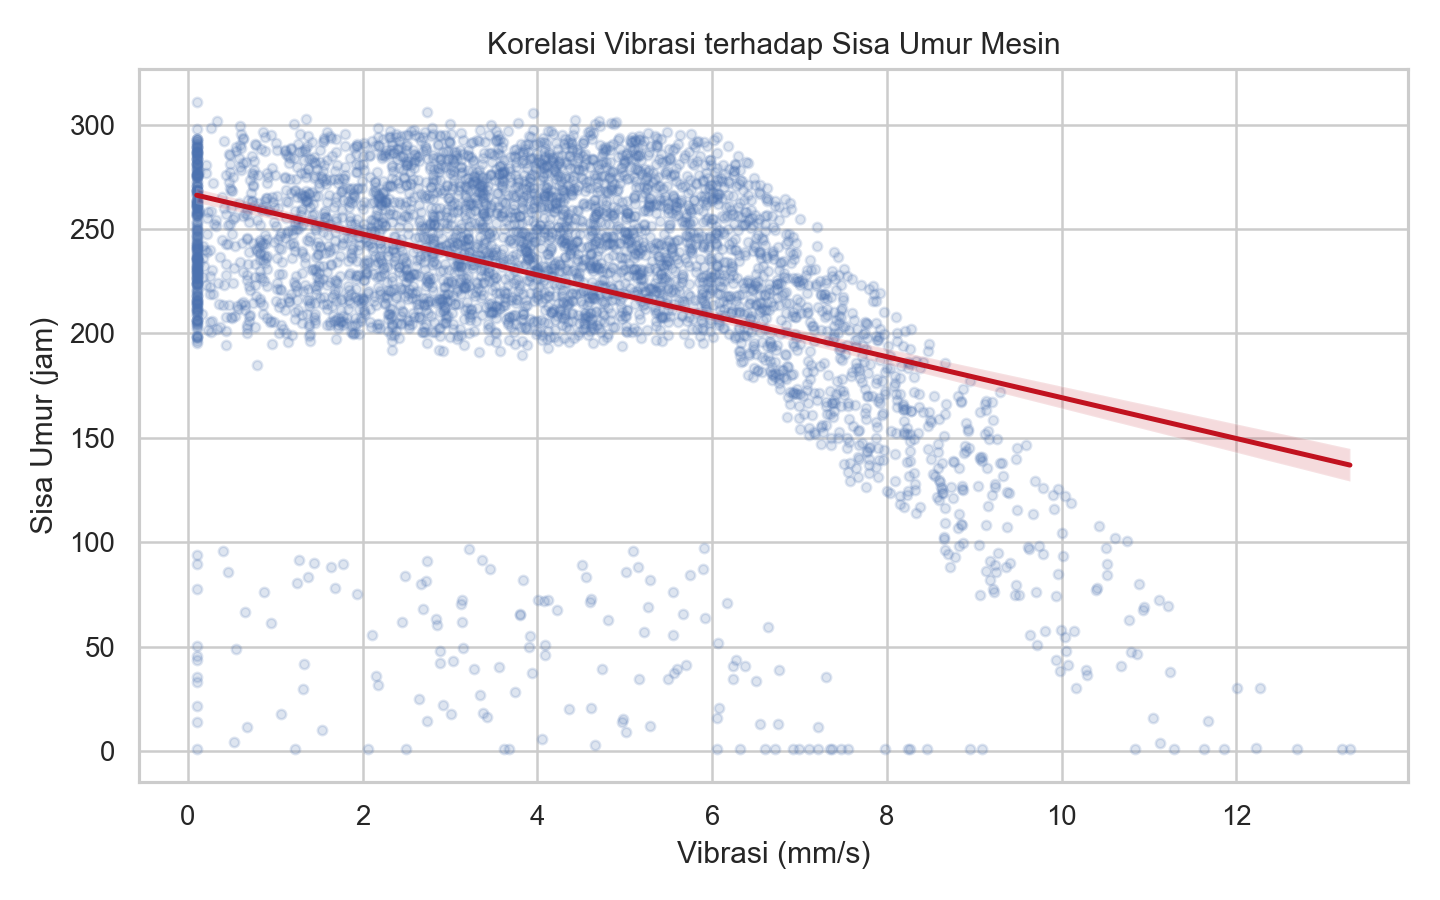

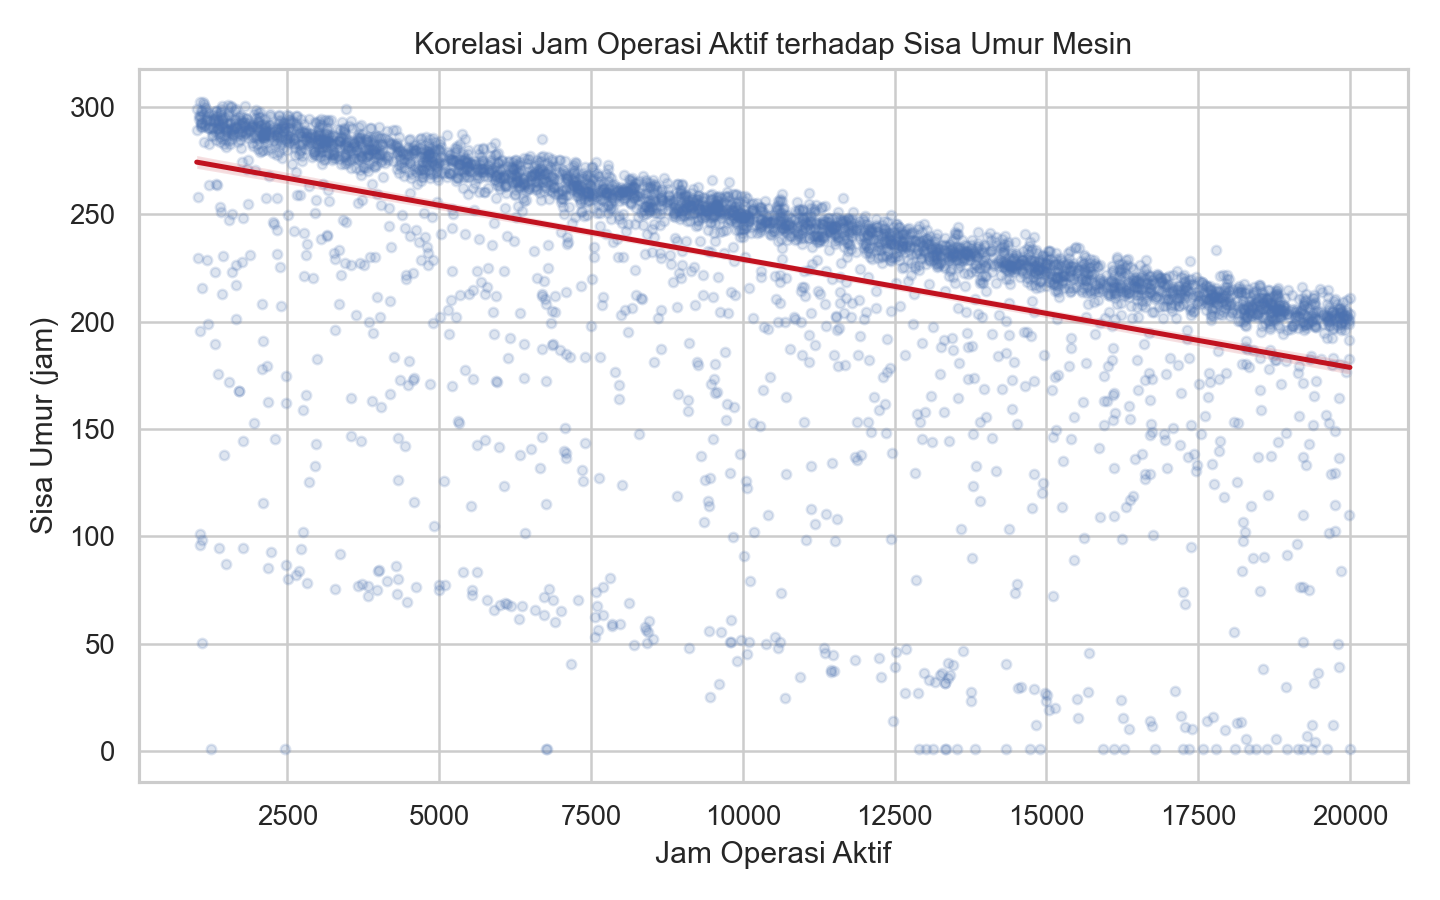

In [5]:
plot_files_tahap1 = [
    STAGE1 / 'outputs' / 'plots' / 'heatmap_korelasi_numerik.png',
    STAGE1 / 'outputs' / 'plots' / 'korelasi_vibrasi_vs_sisa_umur.png',
    STAGE1 / 'outputs' / 'plots' / 'korelasi_jam_operasi_vs_sisa_umur.png',
]

for plot_path in plot_files_tahap1:
    display(Image(filename=str(plot_path)))

Gambar korelasi digunakan untuk membaca hubungan sensor dengan sisa umur mesin. Heatmap memperlihatkan arah hubungan antar fitur numerik. Plot getaran dan jam operasi menunjukkan kecenderungan menurun: semakin tinggi getaran atau semakin lama mesin aktif, sisa umur cenderung lebih pendek. Polanya tidak lurus sempurna karena kondisi mesin dipengaruhi banyak sensor sekaligus.

## B. Metode dan Eksperimen

Prediksi sisa umur mesin dikerjakan sebagai masalah regresi. Kami membandingkan Dummy Mean, Ridge Regression, Decision Tree, Random Forest, dan Gradient Boosting. Model dipilih dari RMSE validasi paling rendah, lalu diuji kembali pada data testing.

Model linear kami wakili dengan Ridge Regression karena sederhana dan bisa menjadi patokan awal. Decision Tree kami pilih karena kondisi mesin bisa berubah berdasarkan batas tertentu, misalnya suhu tinggi atau getaran besar. Random Forest dan Gradient Boosting diuji karena keduanya mengembangkan cara kerja pohon keputusan dan lebih stabil untuk data sensor. Algoritma Genetika dipilih karena hasil akhir yang dicari adalah urutan 50 mesin, sehingga pencarian jadwal lebih cocok dilakukan dengan kromosom permutasi, fitness, crossover, dan mutasi. Logistic Regression, K-Nearest Neighbour, dan Naive Bayes tidak digunakan karena proyek ini tidak memprediksi kelas.

Algoritma Genetika menggunakan hasil prediksi sisa umur sebagai batas aman waktu mulai perbaikan. Alurnya dibuat langsung: model Machine Learning menghasilkan `prediksi_sisa_umur_jam`, kemudian nilai itu diubah menjadi `rul_ga_jam` dengan batas bawah nol sebelum masuk ke proses penjadwalan.

In [6]:
hyperparameter_table = pd.DataFrame([
    {'model': 'Dummy Mean', 'setting': 'strategy=mean'},
    {'model': 'Ridge Regression', 'setting': 'alpha=1.0, random_state=42'},
    {'model': 'Decision Tree', 'setting': 'max_depth=8, random_state=42'},
    {'model': 'Random Forest', 'setting': 'n_estimators=120, max_depth=14, min_samples_leaf=2, random_state=42'},
    {'model': 'Gradient Boosting', 'setting': 'n_estimators=180, learning_rate=0.06, max_depth=3, random_state=42'},
])

display(hyperparameter_table)

,model,setting
0,Dummy Mean,strategy=mean
1,Ridge Regression,"alpha=1.0, random_state=42"
2,Decision Tree,"max_depth=8, random_state=42"
3,Random Forest,"n_estimators=120, max_depth=14, min_samples_le..."
4,Gradient Boosting,"n_estimators=180, learning_rate=0.06, max_dept..."


Tabel hyperparameter mencatat setting utama setiap model. Tujuannya agar percobaan bisa dijalankan ulang dengan hasil yang sama dan perbandingan antar model tetap jelas.

In [7]:
ga_design_table = pd.DataFrame([
    {'komponen': 'Arsitektur integrasi', 'nilai': ga_design['arsitektur']},
    {'komponen': 'Output ML untuk GA', 'nilai': ga_design['output_ml_untuk_ga']},
    {'komponen': 'Representasi kromosom', 'nilai': ga_design['tipe_kromosom']},
    {'komponen': 'Fungsi fitness', 'nilai': ga_design['rumus_fitness']},
    {'komponen': 'Crossover', 'nilai': integration_summary['crossover']},
    {'komponen': 'Mutasi', 'nilai': integration_summary['mutation']},
    {'komponen': 'Seleksi', 'nilai': integration_summary['selection']},
    {'komponen': 'Population size', 'nilai': integration_summary['population_size']},
    {'komponen': 'Generasi', 'nilai': integration_summary['generations']},
    {'komponen': 'Random seed', 'nilai': integration_summary['random_seed']},
])

display(ga_design_table)
print('Batasan jadwal:')
for batasan in ga_design['batasan_mutlak']:
    print('-', batasan)

,komponen,nilai
0,Arsitektur integrasi,Opsi A - Pra-Komputasi
1,Output ML untuk GA,"rul_ga_jam = max(0, prediksi_sisa_umur_jam)"
2,Representasi kromosom,Permutasi 50 machine_code
3,Fungsi fitness,fitness = 1 / (1 + 10000*breakdown_count + 100...
4,Crossover,Order Crossover (OX)
5,Mutasi,swap + inversion mutation
6,Seleksi,Tournament selection size 3 + elitism 2
7,Population size,100
8,Generasi,60
9,Random seed,42


Batasan jadwal:
- Setiap machine_code muncul tepat satu kali.
- Tidak boleh ada duplikasi atau mesin hilang.
- Satu tim teknisi mengerjakan satu mesin pada satu waktu.
- Perbaikan bersifat non-preemptive: satu perbaikan diselesaikan sebelum pindah ke mesin berikutnya.


Tabel desain Algoritma Genetika menjelaskan bentuk solusi yang dicari. Kromosom berupa urutan mesin, fitness menilai kualitas jadwal, dan operator evolusi mengubah urutan tersebut untuk mencari hasil yang lebih baik. Batasan jadwal menjaga agar setiap mesin tetap muncul satu kali dan teknisi bekerja secara berurutan.

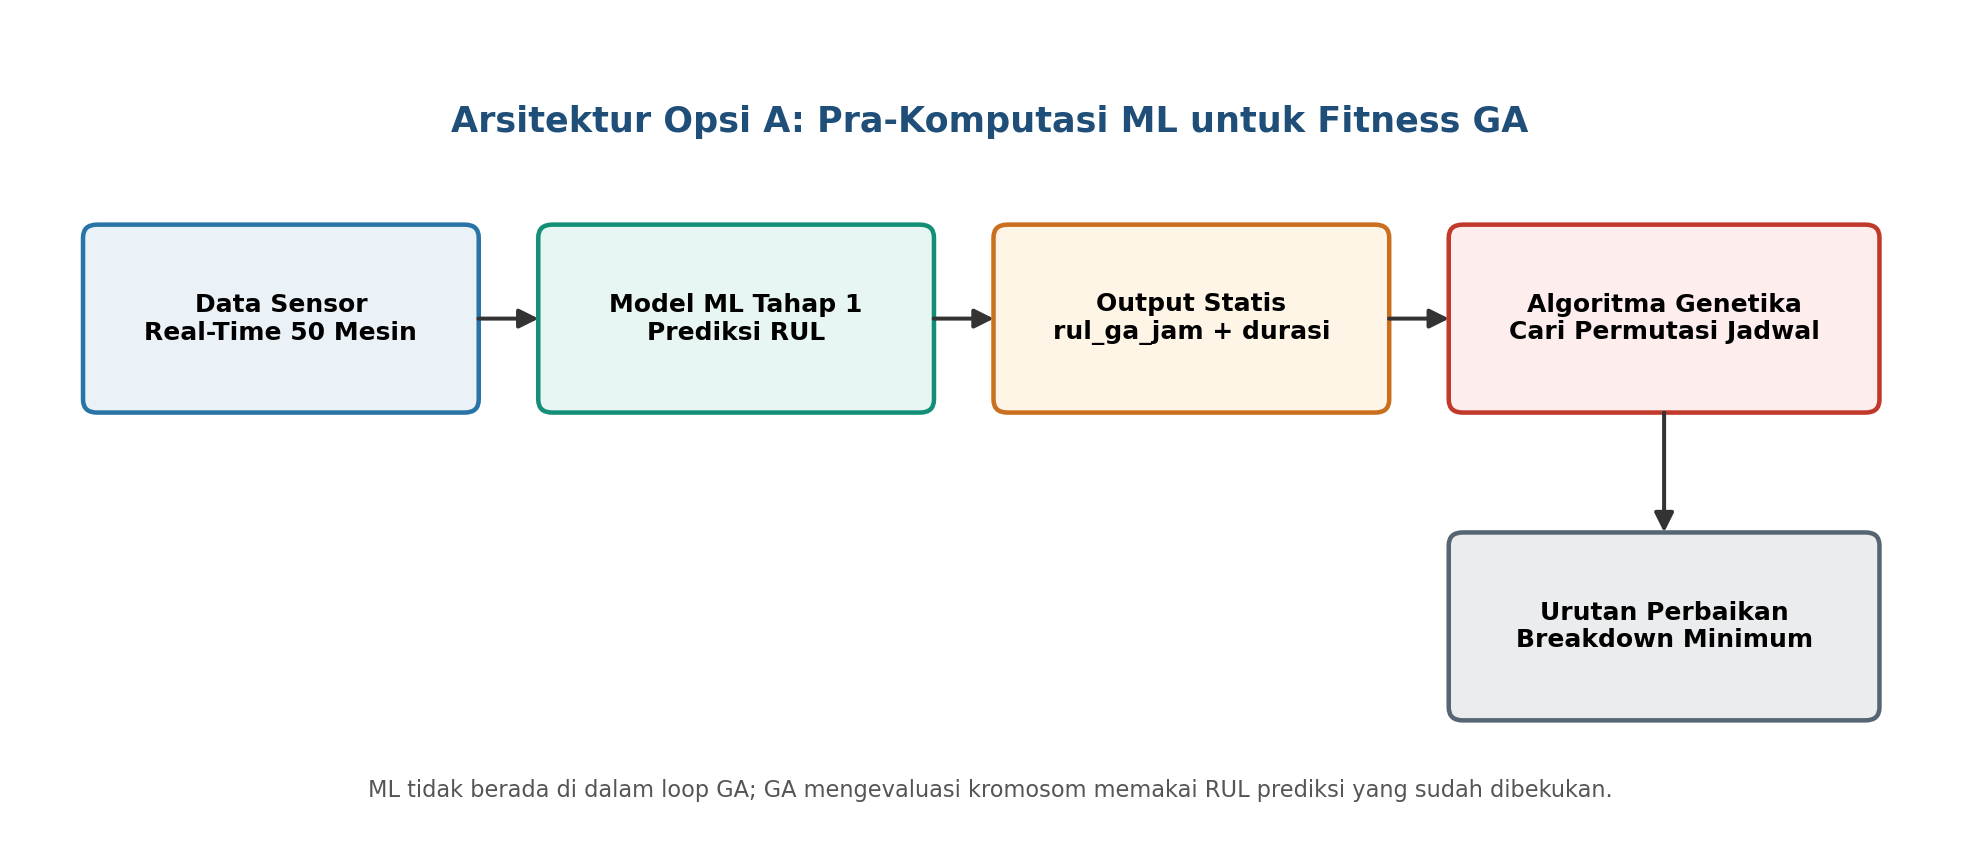

In [8]:
display(Image(filename=str(STAGE2 / 'outputs' / 'plots' / 'tahap2_arsitektur_integrasi_ga.png')))

Gambar arsitektur menunjukkan alur kerja proyek. Model prediksi berjalan lebih dulu untuk menghasilkan sisa umur mesin. Setelah itu, Algoritma Genetika menggunakan hasil prediksi dan durasi perbaikan untuk menyusun jadwal.

## C. Hasil dan Analisis

Evaluasi model menggunakan RMSE, MAE, dan R2. RMSE dan MAE menunjukkan besar kesalahan prediksi dalam satuan jam. R2 menunjukkan seberapa kuat model mengikuti pola target.

In [9]:
metrics_display = model_metrics.copy()
metric_cols = [col for col in metrics_display.columns if col != 'model']
metrics_display[metric_cols] = metrics_display[metric_cols].round(4)
display(metrics_display)

best_ml = metrics_display.iloc[0]
print('Model terbaik berdasarkan RMSE validasi:', best_ml['model'])
print(f"Validasi - RMSE: {best_ml['val_RMSE']:.4f}, MAE: {best_ml['val_MAE']:.4f}, R2: {best_ml['val_R2']:.4f}")
print(f"Testing  - RMSE: {best_ml['test_RMSE']:.4f}, MAE: {best_ml['test_MAE']:.4f}, R2: {best_ml['test_R2']:.4f}")

,model,val_RMSE,val_MAE,val_R2,test_RMSE,test_MAE,test_R2
0,Gradient Boosting,7.3767,5.2391,0.9847,7.3465,5.3481,0.9840
1,Random Forest,7.5087,4.5131,0.9841,7.5723,4.7003,0.9830
2,Decision Tree,8.2008,4.7656,0.9810,9.5071,5.1861,0.9732
3,Ridge Regression,44.2760,28.5775,0.4473,42.0814,27.0262,0.4749
4,Dummy Mean,59.6427,40.6108,-0.0029,58.0846,39.9528,-0.0005


Model terbaik berdasarkan RMSE validasi: Gradient Boosting
Validasi - RMSE: 7.3767, MAE: 5.2391, R2: 0.9847
Testing  - RMSE: 7.3465, MAE: 5.3481, R2: 0.9840


Tabel metrik menunjukkan perbandingan performa model. Gradient Boosting berada di posisi terbaik karena error validasinya paling kecil. Nilai R2 yang tinggi menunjukkan prediksi model mengikuti pola target dengan baik.

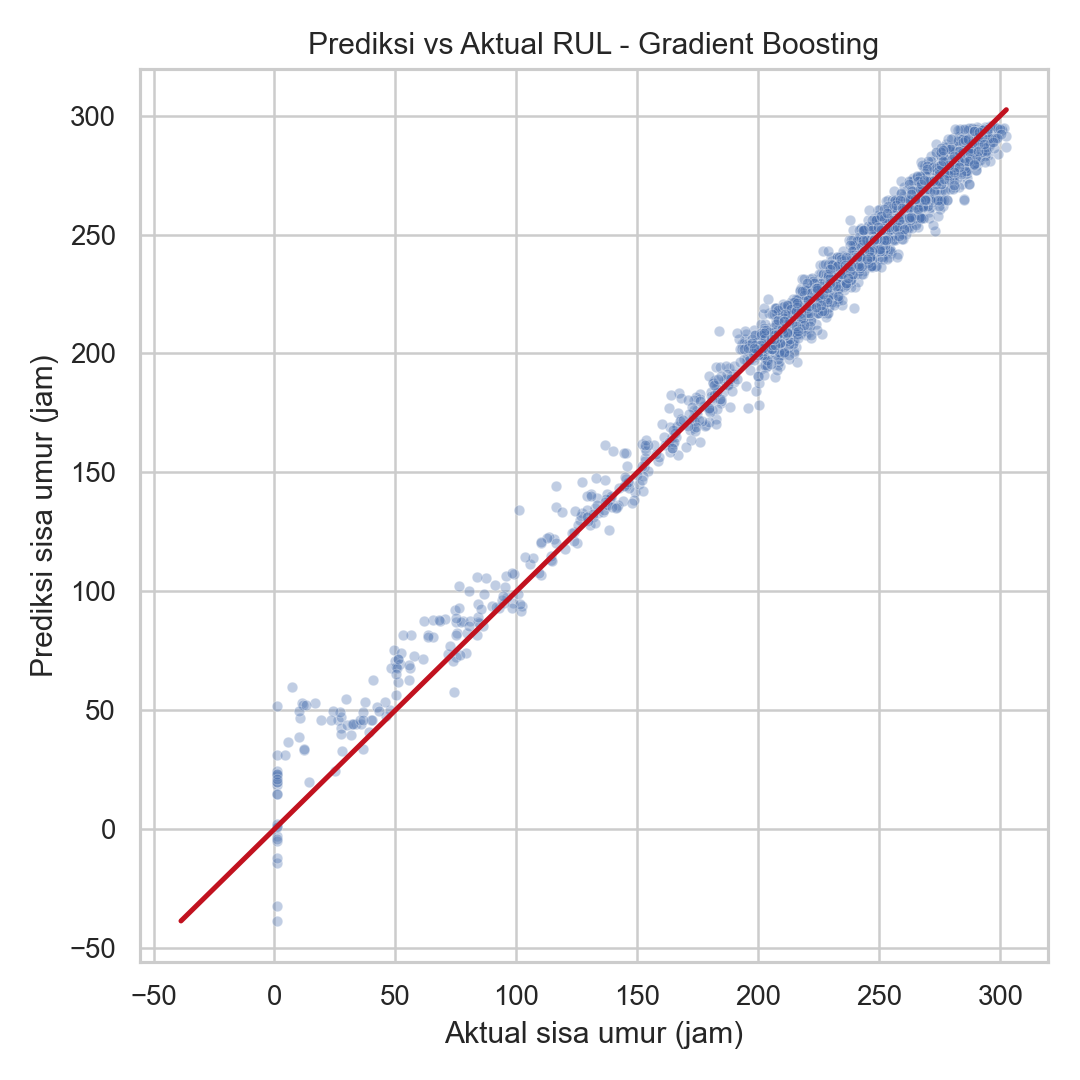

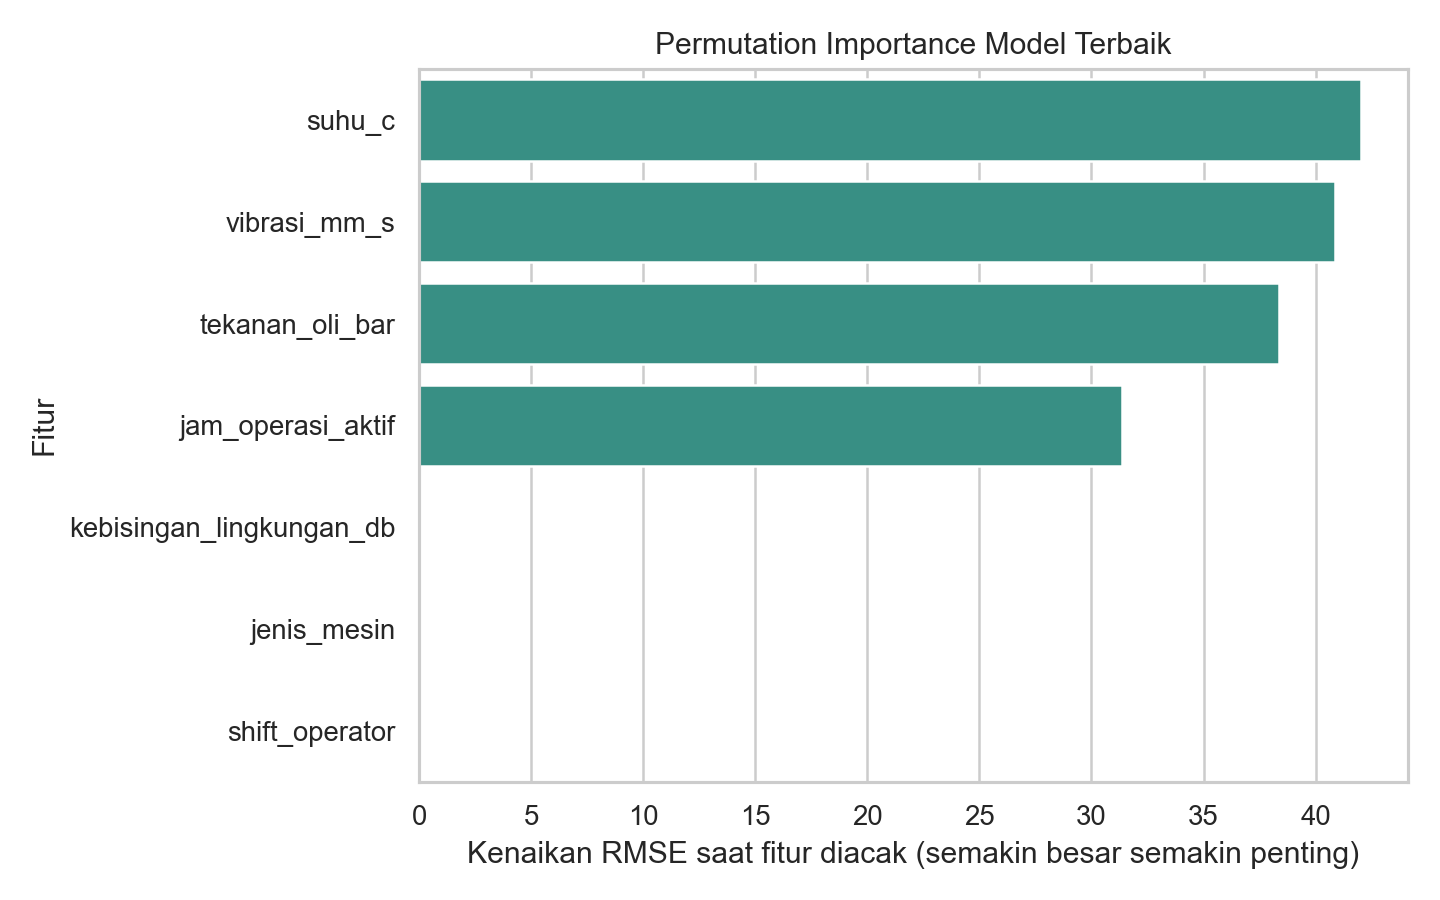

In [10]:
plot_files_model = [
    STAGE1 / 'outputs' / 'plots' / 'prediksi_vs_aktual_gradient_boosting.png',
    STAGE1 / 'outputs' / 'plots' / 'permutation_importance_gradient_boosting.png',
]

for plot_path in plot_files_model:
    display(Image(filename=str(plot_path)))

Grafik prediksi vs aktual digunakan untuk melihat kedekatan hasil prediksi dengan nilai sebenarnya. Titik yang dekat dengan garis ideal berarti prediksi cukup akurat. Grafik feature importance menunjukkan fitur mana yang paling besar pengaruhnya dalam prediksi sisa umur mesin.

Gradient Boosting menjadi model terbaik karena RMSE validasinya paling rendah. Nilai R2 validasi dan testing berada di sekitar 0.984. Hasil ini menunjukkan bahwa pola sisa umur mesin lebih kuat ditangkap oleh model berbasis pohon dibanding model linear.

### Hasil Integrasi Algoritma Genetika

Evaluasi jadwal berfokus pada jumlah mesin breakdown, total keterlambatan, total waktu tunggu, makespan, cost, dan fitness. Breakdown diberi bobot terbesar karena tujuan utama kami adalah menekan jumlah mesin yang rusak sebelum mendapat giliran perbaikan.

In [11]:
ga_compare_display = ga_compare.copy()
for col in ['total_lateness_jam', 'total_waiting_jam', 'makespan_jam', 'cost', 'fitness']:
    ga_compare_display[col] = ga_compare_display[col].round(6)

display(ga_compare_display)

best_score = integration_summary['best_score']
best_ga_table = pd.DataFrame([
    {'metrik': 'Fitness terbaik', 'nilai': best_score['fitness']},
    {'metrik': 'Cost terbaik', 'nilai': best_score['cost']},
    {'metrik': 'Breakdown count', 'nilai': best_score['breakdown_count']},
    {'metrik': 'Total lateness jam', 'nilai': best_score['total_lateness_jam']},
    {'metrik': 'Total waiting jam', 'nilai': best_score['total_waiting_jam']},
    {'metrik': 'Makespan jam', 'nilai': best_score['makespan_jam']},
])
display(best_ga_table)

,jadwal,breakdown_count,total_lateness_jam,total_waiting_jam,makespan_jam,cost,fitness
0,SPT_durasi_terpendek,46,"5,956.5900","6,417.0000",342.0000,"1,055,723.1700",0.0000
1,EDD_RUL_terpendek,49,"7,348.8700","7,834.0000",342.0000,"1,224,965.3400",0.0000
2,FCFS_input_awal,47,"7,954.9600","8,396.0000",342.0000,"1,265,579.9600",0.0000


,metrik,nilai
0,Fitness terbaik,0.0000
1,Cost terbaik,"1,025,043.8700"
2,Breakdown count,42.0000
3,Total lateness jam,"6,049.7900"
4,Total waiting jam,"6,487.0000"
5,Makespan jam,342.0000


Tabel pembanding jadwal menunjukkan posisi hasil awal sebelum evolusi penuh. Tabel skor terbaik menunjukkan hasil akhir Algoritma Genetika. Fokus utama ada pada `breakdown_count`, karena tujuan proyek adalah mengurangi mesin yang rusak saat menunggu giliran perbaikan.

In [12]:
assert len(best_schedule) == 50
assert best_schedule['machine_code'].nunique() == 50
assert int(best_schedule['breakdown_saat_menunggu'].sum()) == integration_summary['best_score']['breakdown_count']
assert round(float(best_schedule['durasi_perbaikan_jam'].sum()), 2) == integration_summary['best_score']['makespan_jam']

print('Validasi jadwal akhir berhasil.')
print('Jumlah baris jadwal:', len(best_schedule))
print('Jumlah machine_code unik:', best_schedule['machine_code'].nunique())
print('Breakdown pada jadwal akhir:', int(best_schedule['breakdown_saat_menunggu'].sum()))
print('Total durasi perbaikan:', float(best_schedule['durasi_perbaikan_jam'].sum()), 'jam')

display(best_schedule.head(15))

Validasi jadwal akhir berhasil.
Jumlah baris jadwal: 50
Jumlah machine_code unik: 50
Breakdown pada jadwal akhir: 42
Total durasi perbaikan: 342.0 jam


,urutan,machine_code,id_log_sensor,jenis_mesin,rul_ga_jam,durasi_perbaikan_jam,mulai_jam,selesai_jam,breakdown_saat_menunggu,keterlambatan_jam
0,1,M30,LOG-03721,CNC_Milling,0.0000,2,0.0000,2.0000,0,0.0000
1,2,M46,LOG-06138,Conveyor_Belt,0.0000,3,2.0000,5.0000,1,2.0000
2,3,M23,LOG-03107,Robot_Arm,23.0300,3,5.0000,8.0000,0,0.0000
3,4,M01,LOG-00016,CNC_Milling,17.0500,3,8.0000,11.0000,0,0.0000
4,5,M14,LOG-01447,Robot_Arm,23.6400,4,11.0000,15.0000,0,0.0000
5,6,M37,LOG-04444,CNC_Milling,15.8300,6,15.0000,21.0000,0,0.0000
6,7,M31,LOG-03899,CNC_Milling,24.5100,4,21.0000,25.0000,0,0.0000
7,8,M47,LOG-06325,Robot_Arm,27.5400,5,25.0000,30.0000,0,0.0000
8,9,M03,LOG-00388,Robot_Arm,31.3200,6,30.0000,36.0000,0,0.0000
9,10,M11,LOG-01255,Conveyor_Belt,0.0000,2,36.0000,38.0000,1,36.0000


Validasi jadwal memastikan hasil akhir berisi 50 mesin unik, jumlah breakdown sesuai ringkasan, dan total durasi sama dengan makespan. Tabel 15 baris pertama menunjukkan urutan awal perbaikan yang akan dikerjakan teknisi.

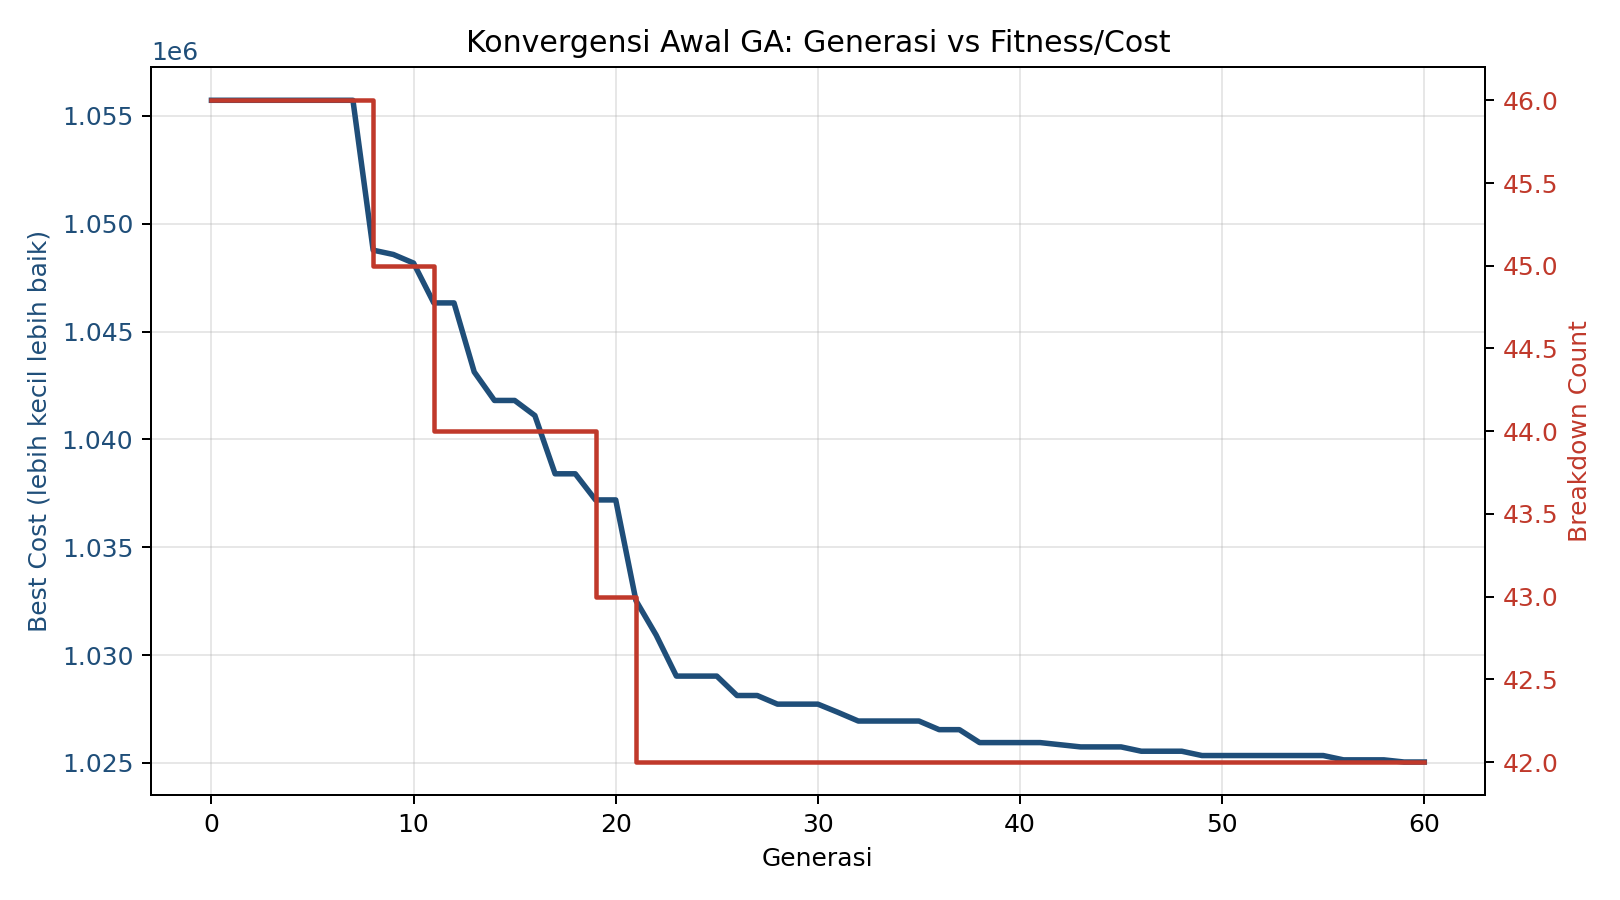

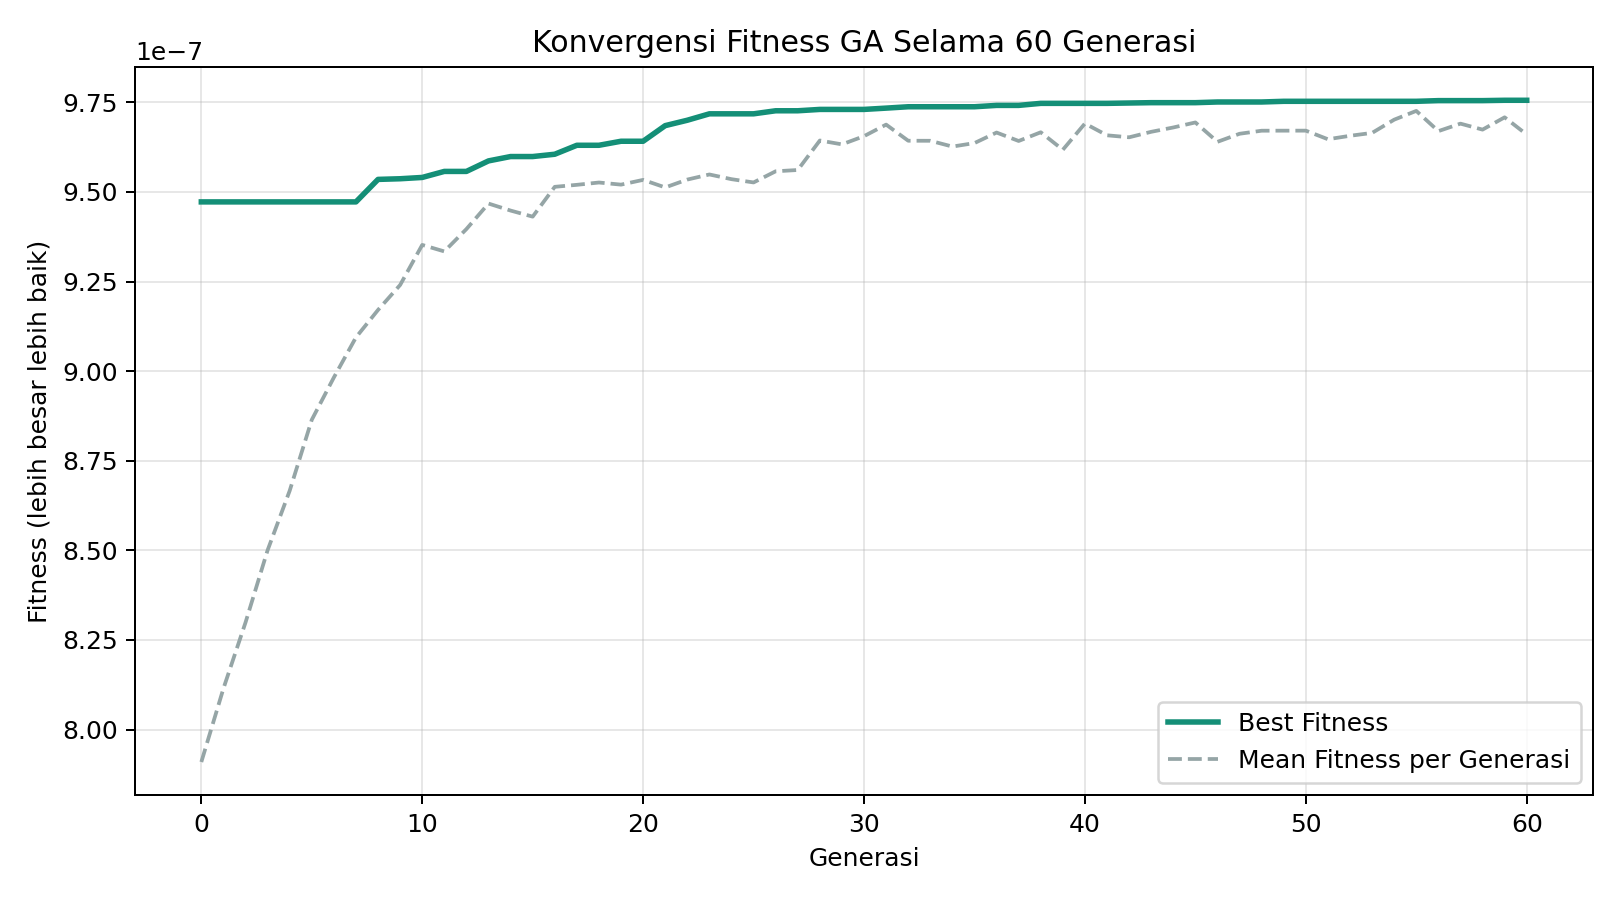

,generation,best_fitness,best_cost,best_breakdown_count,best_total_lateness_jam,generation_mean_fitness,generation_best_fitness,generation_best_cost
51,51,0.0000,"1,025,343.9000",42,"6,052.7900",0.0000,0.0000,"1,025,343.9000"
52,52,0.0000,"1,025,343.9000",42,"6,052.7900",0.0000,0.0000,"1,025,343.9000"
53,53,0.0000,"1,025,343.9000",42,"6,052.7900",0.0000,0.0000,"1,025,343.9000"
54,54,0.0000,"1,025,343.9000",42,"6,052.7900",0.0000,0.0000,"1,025,343.9000"
55,55,0.0000,"1,025,343.9000",42,"6,052.7900",0.0000,0.0000,"1,025,343.9000"
56,56,0.0000,"1,025,143.8800",42,"6,050.7900",0.0000,0.0000,"1,025,143.8800"
57,57,0.0000,"1,025,143.8800",42,"6,050.7900",0.0000,0.0000,"1,025,143.8800"
58,58,0.0000,"1,025,143.8800",42,"6,050.7900",0.0000,0.0000,"1,025,143.8800"
59,59,0.0000,"1,025,043.8700",42,"6,049.7900",0.0000,0.0000,"1,025,043.8700"
60,60,0.0000,"1,025,043.8700",42,"6,049.7900",0.0000,0.0000,"1,025,043.8700"


In [13]:
for plot_path in [
    STAGE3 / 'outputs' / 'plots' / 'tahap3_ga_convergence.png',
    STAGE3 / 'outputs' / 'plots' / 'tahap3_ga_fitness_curve.png',
]:
    display(Image(filename=str(plot_path)))

history_tail = history.tail(10).copy()
for col in history_tail.columns:
    if col != 'generation':
        history_tail[col] = history_tail[col].round(6)
display(history_tail)

Grafik dan tabel generasi akhir menunjukkan proses pencarian solusi berjalan stabil. Jika fitness membaik dan cost menurun, berarti Algoritma Genetika berhasil menemukan jadwal yang lebih baik dari generasi awal.

Algoritma Genetika berjalan dari generasi 0 sampai 60. Jadwal pembanding terbaik pada Tahap 2 adalah SPT dengan 46 breakdown dan cost 1,055,723.17. Jadwal akhir dari Algoritma Genetika menghasilkan 42 breakdown dan cost 1,025,043.87. Jumlah breakdown turun 4 mesin, sedangkan makespan tetap 342 jam.

## D. Kesimpulan

Kami menyelesaikan Problem 12 Manufaktur dengan dua proses utama. Machine Learning memprediksi sisa umur mesin dari data sensor dan operasional. Algoritma Genetika menyusun urutan perbaikan 50 mesin berdasarkan hasil prediksi dan durasi perbaikan.

Model terbaik adalah Gradient Boosting dengan RMSE validasi 7.3767, MAE validasi 5.2391, R2 validasi 0.9847, RMSE testing 7.3465, MAE testing 5.3481, dan R2 testing 0.9840.

Jadwal terbaik dari Algoritma Genetika mencapai fitness 0.0000009756, cost 1,025,043.87, breakdown count 42, total lateness 6,049.79 jam, total waiting 6,487.00 jam, dan makespan 342.00 jam. Dibanding jadwal pembanding terbaik Tahap 2, jumlah breakdown turun dari 46 menjadi 42 mesin. Hasil ini menunjukkan bahwa prediksi sisa umur mesin dapat digunakan untuk menyusun antrean perbaikan yang lebih baik untuk satu tim teknisi.